<a href="https://colab.research.google.com/github/IrfanKpm/ai-with-huggingface/blob/main/ch03_diffusion_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Image Processing

In [23]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
pic = Image.open("/content/white-flower.jpg")

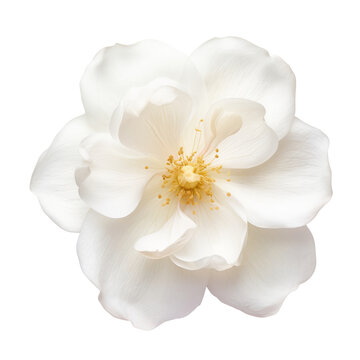

In [ ]:
pic

In [ ]:
type(pic)

PIL.JpegImagePlugin.JpegImageFile

In [ ]:
pic_array = np.asarray(pic)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
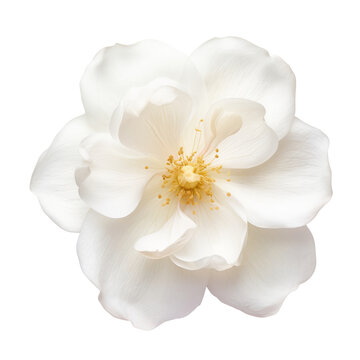

In [ ]:
pic_array

In [ ]:
pic_array.shape

(360, 360, 3)

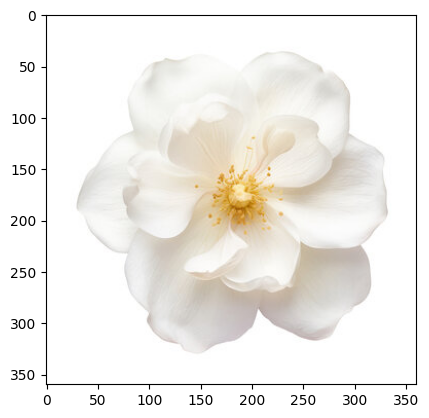

In [ ]:
plt.imshow(pic_array)
plt.show()

In [ ]:
pic_red = pic_array.copy()

# RGB
pic_red[:,:,1] = 0 # Green Channel : set -> 0
pic_red[:,:,2] = 0 # Blue Channel : set -> 0

array([[[255,   0,   0],
        [255,   0,   0],
        [255,   0,   0],
        ...,
        [255,   0,   0],
        [255,   0,   0],
        [255,   0,   0]],

       [[255,   0,   0],
        [255,   0,   0],
        [255,   0,   0],
        ...,
        [255,   0,   0],
        [255,   0,   0],
        [255,   0,   0]],

       [[255,   0,   0],
        [255,   0,   0],
        [255,   0,   0],
        ...,
        [255,   0,   0],
        [255,   0,   0],
        [255,   0,   0]],

       ...,

       [[255,   0,   0],
        [255,   0,   0],
        [255,   0,   0],
        ...,
        [255,   0,   0],
        [255,   0,   0],
        [255,   0,   0]],

       [[255,   0,   0],
        [255,   0,   0],
        [255,   0,   0],
        ...,
        [255,   0,   0],
        [255,   0,   0],
        [255,   0,   0]],

       [[255,   0,   0],
        [255,   0,   0],
        [255,   0,   0],
        ...,
        [255,   0,   0],
        [255,   0,   0],
        [255,   0,   0]]], dtype=uint8)
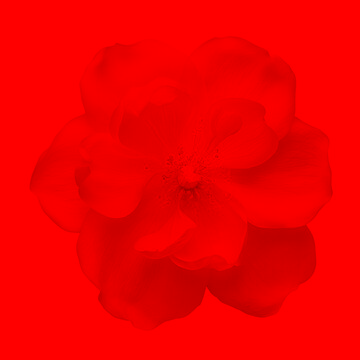

In [ ]:
pic_red

## Generating Faces Using Diffusion Models

In [ ]:
from diffusers import DDPMPipeline

Denoising Diffusion Probabilistic Models (DDPMs) are a class of deep generative models that create high-quality synthetic data (like images, audio, or text) by iteratively reversing a noise-injection process. They have become the foundational architecture behind state-of-the-art AI systems like Stable Diffusion.

In [ ]:
pipeline = DDPMPipeline.from_pretrained("google/ddpm-celebahq-256")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [ ]:
pipeline.to("cuda")
image = pipeline().images[0]
image.save("generated_face.png")

  0%|          | 0/1000 [00:00<?, ?it/s]

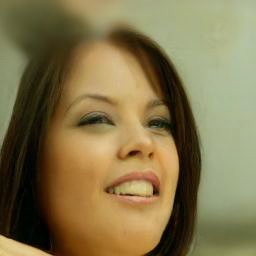

In [ ]:
image

In [1]:
from diffusers import DDPMScheduler,UNet2DModel

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [2]:
scheduler = DDPMScheduler.from_pretrained("google/ddpm-celebahq-256")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


scheduler_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

In [3]:
scheduler

DDPMScheduler {
  "_class_name": "DDPMScheduler",
  "_diffusers_version": "0.38.0",
  "beta_end": 0.02,
  "beta_schedule": "linear",
  "beta_start": 0.0001,
  "clip_sample": true,
  "clip_sample_range": 1.0,
  "dynamic_thresholding_ratio": 0.995,
  "num_train_timesteps": 1000,
  "prediction_type": "epsilon",
  "rescale_betas_zero_snr": false,
  "sample_max_value": 1.0,
  "steps_offset": 0,
  "thresholding": false,
  "timestep_spacing": "leading",
  "trained_betas": null,
  "variance_type": "fixed_small"
}

In [4]:
model = UNet2DModel.from_pretrained("google/ddpm-celebahq-256")

config.json:   0%|          | 0.00/790 [00:00<?, ?B/s]

An error occurred while trying to fetch google/ddpm-celebahq-256: google/ddpm-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


diffusion_pytorch_model.bin:   0%|          | 0.00/455M [00:00<?, ?B/s]

In [5]:
model

UNet2DModel(
  (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=128, out_features=512, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0-1): 2 x DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
          (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Con

In [6]:
scheduler.set_timesteps(50)

In [ ]:
scheduler.set_timesteps

<bound method DDPMScheduler.set_timesteps of DDPMScheduler {
  "_class_name": "DDPMScheduler",
  "_diffusers_version": "0.38.0",
  "beta_end": 0.02,
  "beta_schedule": "linear",
  "beta_start": 0.0001,
  "clip_sample": true,
  "clip_sample_range": 1.0,
  "dynamic_thresholding_ratio": 0.995,
  "num_train_timesteps": 1000,
  "prediction_type": "epsilon",
  "rescale_betas_zero_snr": false,
  "sample_max_value": 1.0,
  "steps_offset": 0,
  "thresholding": false,
  "timestep_spacing": "leading",
  "trained_betas": null,
  "variance_type": "fixed_small"
}
>

In [7]:
import torch

In [8]:
sample_size = model.config.sample_size

In [9]:
sample_size

256

In [10]:
noise = torch.randn((1,3,sample_size),device="cuda")

In [11]:
input = noise

In [12]:
for t in scheduler.timesteps:
    with torch.inference_mode():
        noisy_residual = model(input, t).sample
        prev_noisy_sample = scheduler.step(noisy_residual, t, input).prev_sample
        input = prev_noisy_sample


RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA_addmm)

In [33]:
device = torch.device("cuda")

model = model.to(device)
input = input.to(device)

In [40]:
input = torch.randn((1, 3, 256, 256),device=device)

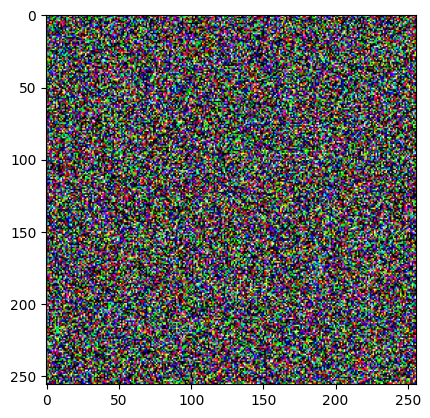

In [41]:
plt.imshow(input.cpu().permute(0,2,3,1)[0])
plt.show()

In [36]:
for t in scheduler.timesteps:
    with torch.inference_mode():
        noisy_residual = model(input, t).sample
        prev_noisy_sample = scheduler.step(noisy_residual, t, input).prev_sample
        input = prev_noisy_sample

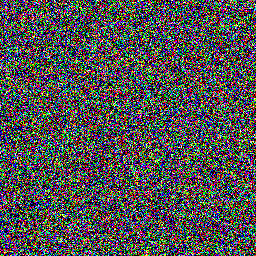

In [38]:
import matplotlib.pyplot as plt
import imageio
import numpy as np

input = torch.randn((1, 3, 256, 256), device=device)
frames = []

for i, t in enumerate(scheduler.timesteps):
    with torch.inference_mode():
        noisy_residual = model(input, t).sample
        prev_noisy_sample = scheduler.step(noisy_residual, t, input).prev_sample
        input = prev_noisy_sample

    if i % 5 == 0:
        img = input.cpu().permute(0, 2, 3, 1)[0].clamp(0, 1).numpy()
        frames.append((img * 255).astype(np.uint8))

# add the final clean image a few extra times so the GIF "holds" on it
frames.extend([frames[-1]] * 10)

imageio.mimsave("diffusion_process.gif", frames, fps=10)

from IPython.display import Image as IPImage
IPImage("diffusion_process.gif")

In [45]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

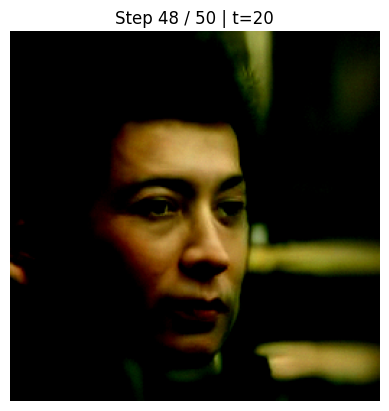

In [52]:
input = torch.randn((1, 3, 256, 256), device=device)

for i, t in enumerate(scheduler.timesteps):
    with torch.inference_mode():
        noisy_residual = model(input, t).sample
        prev_noisy_sample = scheduler.step(noisy_residual, t, input).prev_sample
        input = prev_noisy_sample

    if i % 2 == 0:  # update every 2 steps so it's not too slow
        clear_output(wait=True)
        img = input.cpu().permute(0, 2, 3, 1)[0].clamp(0, 1)
        plt.imshow(img)
        plt.title(f"Step {i} / {len(scheduler.timesteps)} | t={t.item()}")
        plt.axis("off")
        plt.show()